## Entrenamineto 1


In [2]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
def extraer_negativos_xml(img, xml_path):
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    negativos = []

    for obj in root.findall("object"):
        clase = obj.find("name").text

        if clase == "Person":
            continue 

        box = obj.find("bndbox")
        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        crop = img[ymin:ymax, xmin:xmax]
        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (64,128))
        negativos.append(crop)

    return negativos

In [7]:
def extraer_positivos(img, xml_path):
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    positivos = []

    for obj in root.findall("object"):
        if obj.find("name").text != "Person":
            continue

        box = obj.find("bndbox")
        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        crop = img[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (64,128))
        positivos.append(crop)

    return positivos

In [4]:
X = []
y = []
hog = cv2.HOGDescriptor(
    (64,128), (16,16), (8,8), (8,8), 9
)
def get_svm_detector(svm):
    sv = svm.getSupportVectors()
    rho, _, _ = svm.getDecisionFunction(0)
    return np.append(sv.flatten(), -rho)

In [5]:
img_dir = "Person-detection-7/train"
xml_dir = "Person-detection-7/train"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
    
    positivos = extraer_positivos(img, xml_path)
    for p in positivos:
        feat = hog.compute(cv2.cvtColor(p, cv2.COLOR_BGR2GRAY)).flatten()
        X.append(feat)
        y.append(1)
    


NameError: name 'extraer_positivos' is not defined

In [13]:
img_dir = "street-objects-3/train"
xml_dir = "street-objects-3/train"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
        
    negativos = extraer_negativos_xml(img, xml_path)

    for n in negativos:
        feat = hog.compute(cv2.cvtColor(n, cv2.COLOR_BGR2GRAY)).flatten()
        X.append(feat)
        y.append(0)
    

In [14]:
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

In [15]:
svm = cv2.ml.SVM_create()
svm.setType(cv2.ml.SVM_C_SVC)
svm.setKernel(cv2.ml.SVM_LINEAR)
svm.setC(0.01)
svm.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER, 1000, 1e-6))

svm.train(X, cv2.ml.ROW_SAMPLE, y)

svm.save("svm_personas.yml")

In [16]:
_, preds = svm.predict(X)
acc = np.mean(preds.flatten() == y)
print(f"Accuracy (train): {acc:.2f}")


Accuracy (train): 0.95


In [ ]:
img = cv2.imread("Person-detection-7/test/premium_photo-1661292128559-ec5206d3a05a_jpg.rf.a6d7515b6fb07b4cbdf140c4d2fb45f0.jpg")

rects, weights = hog.detectMultiScale(
    img,
    winStride=(8,8),
    padding=(8,8),
    scale=1.05
)

for (x,y,w,h) in rects:
    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

cv2.imwrite("resultado.jpg", img)
print("📸 Resultado guardado")


In [32]:
X_test = []
y_test = []
hog = cv2.HOGDescriptor(
    (64,128), (16,16), (8,8), (8,8), 9
)

img_dir = "Person-detection-7/test"
xml_dir = "Person-detection-7/test"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
    
    positivos = extraer_positivos(img, xml_path)
    for p in positivos:
        feat = hog.compute(cv2.cvtColor(p, cv2.COLOR_BGR2GRAY)).flatten()
        X_test.append(feat)
        y_test.append(1)
    


In [33]:
img_dir = "street-objects-3/test"
xml_dir = "street-objects-3/test"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
        
    negativos = extraer_negativos_xml(img, xml_path)

    for n in negativos:
        feat = hog.compute(cv2.cvtColor(n, cv2.COLOR_BGR2GRAY)).flatten()
        X_test.append(feat)
        y_test.append(0)
    

In [34]:
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.int32)

In [24]:
img = cv2.imread("Person-detection-7/test/GX010023_frame_05385_left_jpg.rf.e9293567015119fd1aece235ab6199aa.jpg")

rects, weights = hog.detectMultiScale(
    img,
    winStride=(8,8),
    padding=(8,8),
    scale=1.05
)

for (x, y, w, h) in rects:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)

cv2.imwrite("resultado_svm.jpg", img)


True

In [30]:
_, preds = svm.predict(X_test)
acc = np.mean(preds.flatten() == y_test) 
print(f"Accuracy (test): {acc:.2f}")

Accuracy (test): 0.97


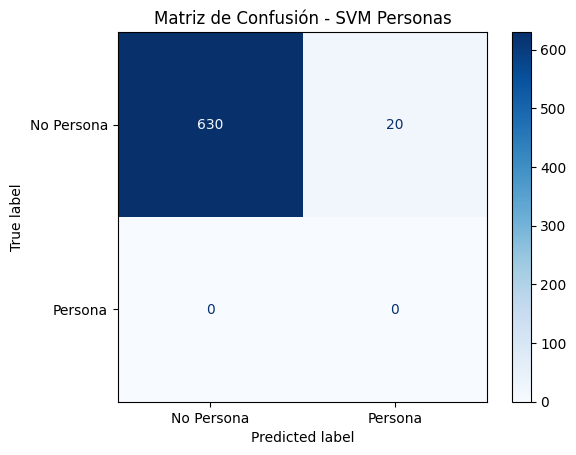

In [35]:
cm = confusion_matrix(y_test, preds, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Persona", "Persona"]
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - SVM Personas")
plt.show()


In [ ]:
svm = cv2.ml.SVM_load("svm_personas.yml")
hog.setSVMDetector(get_svm_detector(svm))

## Entrenamiento 2

In [1]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [8]:
def extraer_positivo(img, xml_path,img_name):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    positivos = []
    i = 0
    for obj in root.findall("object"):
        
        if obj.find("name").text != "person" and obj.find("name").text != "Persona" and obj.find("name").text != "Person":
            continue

        box = obj.find("bndbox")
        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        crop = img[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            continue
        
        crop = cv2.resize(crop, (128,256))
        
        ruta_salida = f"Personas/{img_name}_{i}.jpg"
        print(ruta_salida)
        
        cv2.imwrite(ruta_salida, crop)
        
        i+=1

        positivos.append(crop)
        
    return positivos

In [ ]:
def extraer_negativos(img, xml_path):
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    negativos = []

    for obj in root.findall("object"):
        clase = obj.find("name").text

        if clase == "Person" :
            continue 

        box = obj.find("bndbox")
        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        crop = img[ymin:ymax, xmin:xmax]
        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (64,128))
        negativos.append(crop)

    return negativos

In [24]:
X = []
y = []
hog = cv2.HOGDescriptor(
    (64,128), (16,16), (8,8), (8,8), 9
)
def get_svm_detector(svm):
    sv = svm.getSupportVectors()
    rho, _, _ = svm.getDecisionFunction(0)
    return np.append(sv.flatten(), -rho)

In [9]:
img_dir = "Person-detection-7/train"
xml_dir = "Person-detection-7/train"

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    xml_path = os.path.join(xml_dir, xml_name)

    if not os.path.exists(xml_path):
        print(f"⚠ XML no encontrado para {img_name}")
        continue

    img = cv2.imread(img_path)
    
    if img is None:
        
        continue
    
    extraer_positivo(img, xml_path,img_name)

Personas/photo-1628589588191-79c5b9cfff77_jpg.rf.1e1b6eeb8b103badc31cf91ec6b4f82d.jpg_0.jpg
Personas/photo-1628589588191-79c5b9cfff77_jpg.rf.1e1b6eeb8b103badc31cf91ec6b4f82d.jpg_1.jpg
Personas/photo-1628589588191-79c5b9cfff77_jpg.rf.1e1b6eeb8b103badc31cf91ec6b4f82d.jpg_2.jpg
Personas/photo-1628589588191-79c5b9cfff77_jpg.rf.1e1b6eeb8b103badc31cf91ec6b4f82d.jpg_3.jpg
Personas/GX010023_frame_05414_right_jpg.rf.9a79b4d35ad512834eec126064d65d71.jpg_0.jpg
Personas/GX010023_frame_05414_right_jpg.rf.9a79b4d35ad512834eec126064d65d71.jpg_1.jpg
Personas/photo-1535713875002-d1d0cf377fde_jpg.rf.59d8512a4f4ef7deea7d33ce0d106ae3.jpg_0.jpg
Personas/photo-1523260114198-ce8a8193e83e_jpg.rf.afe6936d40fc25dfa623a86db0e31b54.jpg_0.jpg
Personas/photo-1523260114198-ce8a8193e83e_jpg.rf.afe6936d40fc25dfa623a86db0e31b54.jpg_1.jpg
Personas/photo-1523260114198-ce8a8193e83e_jpg.rf.afe6936d40fc25dfa623a86db0e31b54.jpg_2.jpg
Personas/photo-1523260114198-ce8a8193e83e_jpg.rf.afe6936d40fc25dfa623a86db0e31b54.jpg_3.jpg


In [1]:
import cv2
import os

POS_DIR = "Personas"
OUTPUT_TXT = "pos.txt"

exts = (".jpg", ".jpeg", ".png", ".bmp")

with open(OUTPUT_TXT, "w") as f:
    for img_name in sorted(os.listdir(POS_DIR)):
        if not img_name.lower().endswith(exts):
            continue

        img_path = os.path.join(POS_DIR, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print(f"⚠️ No se pudo leer {img_path}")
            continue

        h, w = img.shape[:2]

        
        x, y = 0, 0
        bbox_w, bbox_h = w, h

        if w > 48  and  h > 96 :
            f.write(f"/cascade/{img_path} 1 {x} {y} {bbox_w} {bbox_h}\n")

print("✅ positives.txt creado correctamente")


✅ positives.txt creado correctamente


In [5]:
import cv2

CASCADE_PATH = "cascade.xml"

cascade = cv2.CascadeClassifier(CASCADE_PATH)
if cascade.empty():
    raise IOError("No se pudo cargar el cascade.xml")

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("No se pudo abrir la cámara")

print("Presiona ESC para salir")
print("Teclas:")
print("  s/S: Aumentar/Disminuir scaleFactor")
print("  n/N: Aumentar/Disminuir minNeighbors")
print("  m/M: Aumentar/Disminuir minSize")

# Parámetros ajustables en tiempo real
scaleFactor = 1.1
minNeighbors = 15  # MÁS ALTO = menos falsos positivos
minSize = (48, 96)  # Doble del tamaño de entrenamiento (24x24 -> 48x96)
maxSize = (200, 400)  # Limitar tamaño máximo

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Ecualización de histograma para mejorar contraste
    gray = cv2.equalizeHist(gray)

    # Detección con parámetros más estrictos
    detections = cascade.detectMultiScale(
        gray,
        scaleFactor=scaleFactor,
        minNeighbors=minNeighbors,
        minSize=minSize,
        maxSize=maxSize,
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    # Dibujar detecciones
    for (x, y, w, h) in detections:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, f"{w}x{h}", (x, y - 5), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    # Mostrar parámetros en pantalla
    info = [
        f"Detecciones: {len(detections)}",
        f"scaleFactor: {scaleFactor:.2f}",
        f"minNeighbors: {minNeighbors}",
        f"minSize: {minSize}"
    ]
    
    y_offset = 30
    for line in info:
        cv2.putText(frame, line, (10, y_offset), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        y_offset += 25

    cv2.imshow("Cascade Camera Test", frame)

    # Controles de teclado
    key = cv2.waitKey(1) & 0xFF
    if key == 27:  # ESC
        break
    elif key == ord('s'):
        scaleFactor = min(2.0, scaleFactor + 0.05)
        print(f"scaleFactor: {scaleFactor:.2f}")
    elif key == ord('S'):
        scaleFactor = max(1.01, scaleFactor - 0.05)
        print(f"scaleFactor: {scaleFactor:.2f}")
    elif key == ord('n'):
        minNeighbors += 1
        print(f"minNeighbors: {minNeighbors}")
    elif key == ord('N'):
        minNeighbors = max(1, minNeighbors - 1)
        print(f"minNeighbors: {minNeighbors}")
    elif key == ord('m'):
        minSize = (minSize[0] + 10, minSize[1] + 20)
        print(f"minSize: {minSize}")
    elif key == ord('M'):
        minSize = (max(24, minSize[0] - 10), max(48, minSize[1] - 20))
        print(f"minSize: {minSize}")

cap.release()
cv2.destroyAllWindows()

Presiona ESC para salir
Teclas:
  s/S: Aumentar/Disminuir scaleFactor
  n/N: Aumentar/Disminuir minNeighbors
  m/M: Aumentar/Disminuir minSize
minSize: (58, 116)
minSize: (68, 136)
minSize: (78, 156)
minSize: (88, 176)
scaleFactor: 1.15
scaleFactor: 1.20
scaleFactor: 1.25
scaleFactor: 1.30
scaleFactor: 1.35
scaleFactor: 1.40
scaleFactor: 1.45
scaleFactor: 1.50
scaleFactor: 1.55
minNeighbors: 16
minNeighbors: 17
minNeighbors: 18
minNeighbors: 19
minNeighbors: 20
minNeighbors: 21
minNeighbors: 22
minNeighbors: 23
minNeighbors: 24
minNeighbors: 25
minNeighbors: 26
minNeighbors: 27
minNeighbors: 28
minNeighbors: 29
minNeighbors: 30
minNeighbors: 31
minNeighbors: 32
minNeighbors: 33
minNeighbors: 34
minNeighbors: 35
minNeighbors: 36
minNeighbors: 37
minNeighbors: 38
minNeighbors: 39
minNeighbors: 40
minNeighbors: 41
minNeighbors: 42
minNeighbors: 43
minNeighbors: 44
minNeighbors: 45
minNeighbors: 46
minNeighbors: 47
minNeighbors: 48
minNeighbors: 49
minNeighbors: 50
minNeighbors: 51
minNeig

In [ ]:
img_dir = "Ania/"


for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    img_path = os.path.join(img_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Sobel en X y Y
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    # Magnitud del gradiente
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    magnitude = np.uint8(255 * magnitude / np.max(magnitude))
    feat = hog.compute(magnitude).flatten()
    X.append(feat)
    y.append(1)
    

In [ ]:
img_dir = "street-objects-3/train"


for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith((".jpg")):
        continue
    
    img_path = os.path.join(img_dir, img_name)
    
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    magnitude = np.uint8(255 * magnitude / np.max(magnitude))
    feat = hog.compute(magnitude).flatten()
    X.append(feat)
    y.append(1)
    


In [20]:
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

In [ ]:
svm = cv2.ml.SVM_create()
svm.setType(cv2.ml.SVM_C_SVC)
svm.setKernel(cv2.ml.SVM_LINEAR)
svm.setC(0.01)
svm.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER, 1000, 1e-6))

svm.train(X, cv2.ml.ROW_SAMPLE, y)


True

In [23]:
_, preds = svm.predict(X)
acc = np.mean(preds.flatten() == y)
print(f"Accuracy (train): {acc:.2f}")


Accuracy (train): 1.00


## Entrenamiento 3

In [1]:
import cv2
import numpy as np
import os
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

# Parámetros
WIN_SIZE = (64, 128)
pos_path = "Ania"
neg_path = "street-objects-3/train"

hog = cv2.HOGDescriptor(
    _winSize=WIN_SIZE,
    _blockSize=(16,16),
    _blockStride=(8,8),
    _cellSize=(8,8),
    _nbins=9
)

features = []
labels = []

def load_images(path, label):
    for file in os.listdir(path):
        img = cv2.imread(os.path.join(path, file))
        if img is None:
            continue
        img = cv2.resize(img, WIN_SIZE)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hog_features = hog.compute(gray)
        features.append(hog_features.flatten())
        labels.append(label)
        if label == 1 and len(features) > 5076:
            break

# Cargar datos
load_images(pos_path, 1)   # personas
print(len(labels))
load_images(neg_path, 0)   # no personas

X = np.array(features)
y = np.array(labels)

print("Total muestras:", len(y))

# División train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenar SVM
svm = LinearSVC(max_iter=10000)
svm.fit(X_train, y_train)

# Evaluación
accuracy = svm.score(X_test, y_test)
print("Accuracy:", accuracy)


5077
Total muestras: 7615
Accuracy: 0.9514116874589625


In [2]:
rho = svm.intercept_[0]
weights = svm.coef_[0]
hog_detector = np.append(weights, -rho)

hog.setSVMDetector(hog_detector)


In [3]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    boxes, _ = hog.detectMultiScale(
        gray,
        winStride=(8,8),
        padding=(8,8),
        scale=1.05
    )

    for (x,y,w,h) in boxes:
        cv2.rectangle(frame, (x,y), (x+w,y+h), (0,255,0), 2)

    cv2.imshow("HOG + SVM", frame)

    if cv2.waitKey(30) == 27:  # ESC
        break

cap.release()
cv2.destroyAllWindows()


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/jhonatan/VisualCodeStudio/VisionComputador/SegundoInteciclo/ProyectoFinalCicloDeteccion/.venv/lib/python3.10/site-packages/cv2/qt/plugins"
QFontDatabase: Cannot find font directory /home/jhonatan/VisualCodeStudio/VisionComputador/SegundoInteciclo/ProyectoFinalCicloDeteccion/.venv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/jhonatan/VisualCodeStudio/VisionComputador/SegundoInteciclo/ProyectoFinalCicloDeteccion/.venv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/jhonatan/VisualCodeStudio/VisionComputador/SegundoInteciclo/ProyectoFinalCicloDeteccion/.venv/lib/python3.10/site-packages